
DEUTSCH ALGORITHM - CONSTANT FUNCTION f(x)=0

QUANTUM CIRCUIT
-----------------------------------------------------------------
     ┌───┐     ┌────────┐┌───┐
q_0: ┤ H ├─────┤0       ├┤ H ├
     ├───┤┌───┐│  Uf(0) │└───┘
q_1: ┤ X ├┤ H ├┤1       ├─────
     └───┘└───┘└────────┘     

MEASUREMENT RESULTS
-----------------------------------------------------------------
Shots                 : 1000
0 count               : 1000
1 count               : 0
Measured P(0)         : 1.0000
Measured P(1)         : 0.0000
Function classification : CONSTANT

THEORETICAL RESULT
-----------------------------------------------------------------
Theoretical P(0)      : 1.0000
Theoretical P(1)      : 0.0000


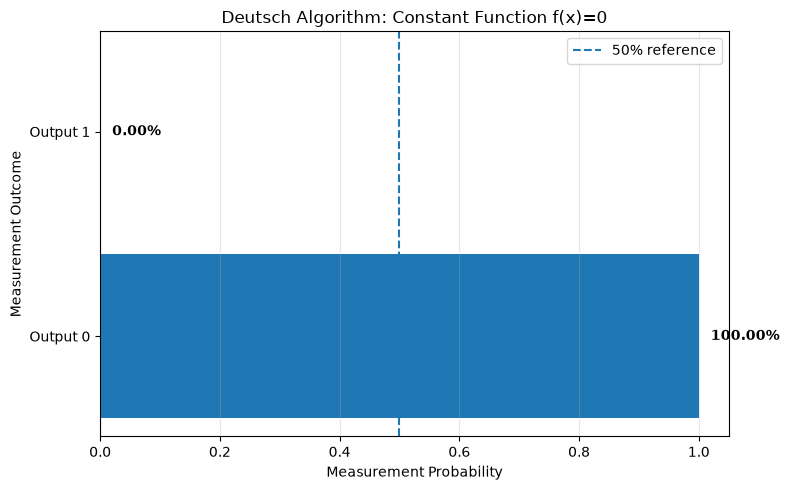

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000

# ---------------------------------------------------------
# CONSTANT ORACLE: f(x) = 0
# ---------------------------------------------------------

oracle = QuantumCircuit(2, name="Uf(0)")

# For f(x)=0, the oracle performs no operation.
# Therefore, Uf is simply the identity operation.

oracle_gate = oracle.to_gate()

# ---------------------------------------------------------
# DEUTSCH ALGORITHM CIRCUIT
# ---------------------------------------------------------

qc = QuantumCircuit(2)

# Prepare control qubit in |+>
qc.h(0)

# Prepare target qubit in |->
qc.x(1)
qc.h(1)

# Apply constant oracle f(x)=0
qc.append(oracle_gate, [0, 1])

# Final Hadamard on control qubit
qc.h(0)

# ---------------------------------------------------------
# STATEVECTOR CALCULATION
# ---------------------------------------------------------

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

# Qubit 0 is the control qubit.
p0 = sum(
    probabilities[i]
    for i in range(len(probabilities))
    if (i & 1) == 0
)

p1 = 1 - p0

# ---------------------------------------------------------
# SIMULATED MEASUREMENT
# ---------------------------------------------------------

rng = np.random.default_rng(42)

samples = rng.choice(
    [0, 1],
    size=SHOTS,
    p=[p0, p1]
)

count0 = int(np.sum(samples == 0))
count1 = int(np.sum(samples == 1))

measured_p0 = count0 / SHOTS
measured_p1 = count1 / SHOTS

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nDEUTSCH ALGORITHM - CONSTANT FUNCTION f(x)=0")
print("=" * 65)

print("\nQUANTUM CIRCUIT")
print("-" * 65)
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 65)

print(f"Shots                 : {SHOTS}")
print(f"0 count               : {count0}")
print(f"1 count               : {count1}")
print(f"Measured P(0)         : {measured_p0:.4f}")
print(f"Measured P(1)         : {measured_p1:.4f}")

if measured_p0 > measured_p1:
    classification = "CONSTANT"
else:
    classification = "BALANCED"

print(f"Function classification : {classification}")

print("\nTHEORETICAL RESULT")
print("-" * 65)
print(f"Theoretical P(0)      : {p0:.4f}")
print(f"Theoretical P(1)      : {p1:.4f}")

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

labels = ["Output 0", "Output 1"]
values = [measured_p0, measured_p1]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(labels, values)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Measurement Probability")
ax.set_ylabel("Measurement Outcome")
ax.set_title("Deutsch Algorithm: Constant Function f(x)=0")

for bar, value in zip(bars, values):
    ax.text(
        value + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2%}",
        va="center",
        fontweight="bold"
    )

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="50% reference"
)

ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()